Dataset Preview:
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  

Model Performance
-----------------------
Mean Absolute Error: 23.672501503146574

Actual vs Predicted AQI:
       Actual AQI  Predicted AQI
8450        141.0          82.

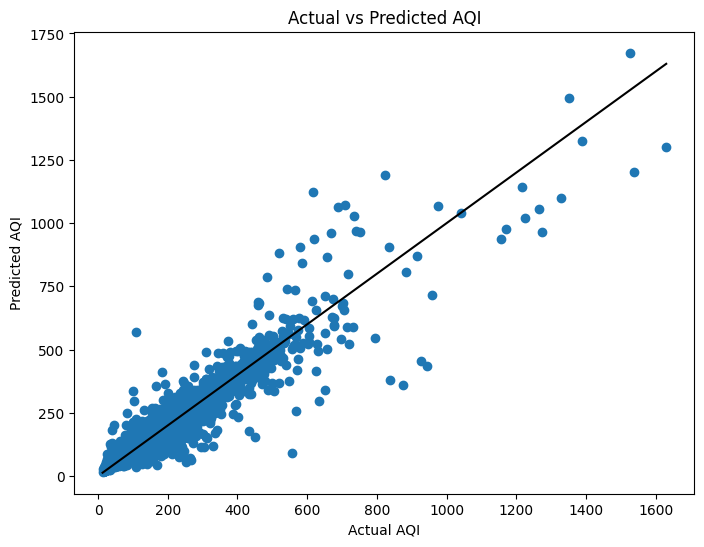


Feature Importance:
  Feature  Importance
0   PM2.5    0.508052
3      CO    0.413242
1    PM10    0.043132
2     NO2    0.035574


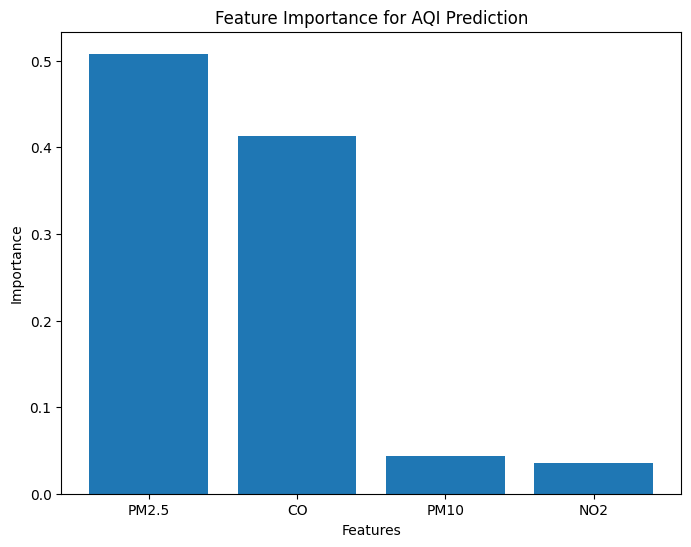


Predicted AQI for new data: 288.25


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================
# AIR QUALITY PREDICTION USING MACHINE LEARNING
# ============================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer # Import for imputation

# 2. Load Dataset
data = pd.read_csv("/content/city_day.csv")

# 3. Display first few rows
print("Dataset Preview:")
print(data.head())

# 4. Select Features (Input variables) and Target
X = data[['PM2.5', 'PM10', 'NO2', 'CO']]
y = data['AQI']

# 5. Handle missing values
# Drop rows where the target variable (y) is NaN
# First, combine X and y to ensure consistent row dropping
df_combined = pd.concat([X, y], axis=1)
df_combined.dropna(subset=['AQI'], inplace=True)

X = df_combined[['PM2.5', 'PM10', 'NO2', 'CO']]
y = df_combined['AQI']

# Impute missing values in features (X) using the mean
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 6. Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Create Random Forest Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# 8. Train Model
model.fit(X_train, y_train)

# 9. Make Predictions
predictions = model.predict(X_test)

# 10. Evaluate Model
mae = mean_absolute_error(y_test, predictions)

print("\nModel Performance")
print("-----------------------")
print("Mean Absolute Error:", mae)

# 11. Compare Actual vs Predicted
comparison = pd.DataFrame({
    "Actual AQI": y_test,
    "Predicted AQI": predictions
})

print("\nActual vs Predicted AQI:")
print(comparison.head(10))

# 12. Plot Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k-') # Added 'k--' for a dashed black line
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.show()

# 13. Feature Importance
importances = model.feature_importances_
features = X.columns

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# 14. Plot Feature Importance
plt.figure(figsize=(8,6))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance for AQI Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# 15. Predict AQI for New Input
new_data_features = pd.DataFrame({
    'PM2.5':[120],
    'PM10':[180],
    'NO2':[60],
    'CO':[1.2]
})

# Impute missing values in the new data using the same imputer fitted on training data
new_data_features_imputed = imputer.transform(new_data_features)

predicted_aqi = model.predict(new_data_features_imputed)

print("\nPredicted AQI for new data:", predicted_aqi[0])

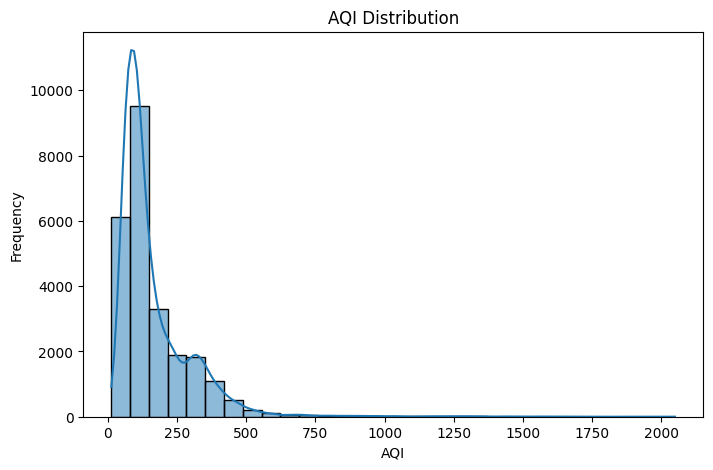

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data['AQI'], bins=30, kde=True)
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()